To build a Physics-Informed Neural Network (PINN) for this dataset, we will first define the governing physical equation (ODE/PDE) that links time, input_voltage, and el_power. Unlike a standard "black-box" model, the PINN will penalize predictions that violate this physical law.

Since the input voltage changes in steps, the system likely behaves like a first-order or second-order dynamic system (e.g., an RC circuit, an inductor, or a thermal heating element).

For example, a common first-order dynamic relationship for electrical power tracking a voltage input is:

$\frac{d(\text{el\_power})}{dt}=\frac{1}{\tau }\left(k\cdot \text{input\_voltage}-\text{el\_power}\right)$

Where $\tau$ is a time constant and $k$ is a gain coefficient. You will need to replace the placeholder in the code below with your system's exact physical equation.

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np

In [2]:

# 1. Define the Neural Network Architecture
class ElectricalPINN(nn.Module):
    def __init__(self):
        super(ElectricalPINN, self).__init__()
        # Input: time (t) and input_voltage (V) -> Output: predicted el_power (P)
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),          # Tanh or GeLU is required for smooth derivatives
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        # Optional: Learnable physical parameters if they are unknown
        self.tau = nn.Parameter(torch.tensor([1.0], requires_grad=True))
        self.k = nn.Parameter(torch.tensor([1.0], requires_grad=True))

    def forward(self, t, V):
        # Combine t and V into a single input tensor
        x = torch.cat([t, V], dim=1)
        return self.net(x)

# 2. Custom Physics-Informed Loss Function
def compute_loss(model, t_data, V_data, P_data, t_collocation, V_collocation):
    # --- Loss 1: Data-Driven Loss (MSE) ---
    P_pred_data = model(t_data, V_data)
    loss_data = nn.MSELoss()(P_pred_data, P_data)
    
    # --- Loss 2: Physics/Residual Loss ---
    # Enable gradient tracking on collocation time points to compute derivatives
    t_collocation.requires_grad_(True)
    
    P_pred_colloc = model(t_collocation, V_collocation)
    
    # Compute d(el_power)/dt using Automatic Differentiation
    dP_dt = torch.autograd.grad(
        P_pred_colloc, t_collocation,
        grad_outputs=torch.ones_like(P_pred_colloc),
        create_graph=True,
        retain_graph=True
    )[0]
    
    # Example ODE Residual: dP/dt - (1/tau) * (k * V - P) = 0
    # REPLACE THIS LINE WITH YOUR ACTUAL PHYSICAL EQUATION
    physics_residual = dP_dt - (1.0 / model.tau) * (model.k * V_collocation - P_pred_colloc)
    loss_physics = torch.mean(physics_residual ** 2)
    
    # --- Total Loss ---
    # lambda_p adjusts the weight of the physical constraint balance
    lambda_p = 0.1 
    total_loss = loss_data + lambda_p * loss_physics
    
    return total_loss, loss_data, loss_physics


Because your time values are extremely small $10^{-6}$ seconds, we must normalize your data before feeding it to the network. Neural networks fail to converge when input gradients span vastly different scales.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

example_files = [
    '../data/train/ex_1.csv',
    '../data/train/ex_20.csv',
    '../data/train/ex_21.csv',
    '../data/train/ex_23.csv',
    '../data/train/ex_24.csv',
    '../data/train/ex_9.csv'
]

dfs = []

for file in example_files:
    temp = pd.read_csv(file)

    # preserve experiment identity
    experiment_id = Path(file).stem
    temp["experiment_id"] = experiment_id

    # parse datetime
    temp["time"] = pd.to_datetime(temp["time"])

    # create relative time (seconds)
    # critical for dynamic modeling
    t0 = temp["time"].min()
    temp["t_sec"] = (
        temp["time"] - t0
    ).dt.total_seconds()

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("Combined shape:", df.shape)
print(df.head())

Combined shape: (52940, 5)
                           time  input_voltage     el_power experiment_id  \
0 1970-01-01 00:00:00.000000810           10.0  1228.791720          ex_1   
1 1970-01-01 00:00:00.000000811           10.0  1223.041745          ex_1   
2 1970-01-01 00:00:00.000000812           10.0  1244.960866          ex_1   
3 1970-01-01 00:00:00.000000813           10.0  1229.259058          ex_1   
4 1970-01-01 00:00:00.000000814           10.0  1248.117024          ex_1   

          t_sec  
0  0.000000e+00  
1  1.000000e-09  
2  2.000000e-09  
3  3.000000e-09  
4  4.000000e-09  


In [4]:
summary = []

for exp, group in df.groupby("experiment_id"):

    dt = group["t_sec"].diff().dropna()

    summary.append({
        "experiment": exp,
        "n_rows": len(group),
        "duration_sec": group["t_sec"].max(),
        "mean_dt": dt.mean(),
        "min_dt": dt.min(),
        "max_dt": dt.max()
    })

summary_df = pd.DataFrame(summary)
summary_df

,experiment,n_rows,duration_sec,mean_dt,min_dt,max_dt
0,ex_1,9920,0.000010,9.990927e-10,0.000000e+00,2.000000e-09
1,ex_20,6495,0.000007,1.074068e-09,1.000000e-09,4.000000e-09
2,ex_21,6495,0.000007,1.066985e-09,1.000000e-09,4.000000e-09
3,ex_23,9188,0.000010,1.104169e-09,1.000000e-09,4.000000e-09
4,ex_24,9023,0.000010,1.082687e-09,1.000000e-09,4.000000e-09
5,ex_9,11819,0.000012,1.000000e-09,1.000000e-09,1.000000e-09


In [5]:
# normalize time inside each experiment
df["t_norm"] = (
    df.groupby("experiment_id")["t_sec"]
      .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
)

# verify
df.groupby("experiment_id")["t_norm"].agg(["min", "max"]).head()

,min,max
experiment_id,,
ex_1,0.0,1.0
ex_20,0.0,1.0
ex_21,0.0,1.0
ex_23,0.0,1.0
ex_24,0.0,1.0


In [6]:
import numpy as np

def compute_derivative(group):

    group = group.sort_values("t_norm").copy()

    t = group["t_norm"].values
    p = group["el_power"].values

    # numerical derivative
    dpdt = np.gradient(p, t)

    group["dpdt"] = dpdt

    return group


df_dyn = (
    df.groupby("experiment_id", group_keys=False)
      .apply(compute_derivative)
)

df_dyn.head()

/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1328: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] \


,time,input_voltage,el_power,t_sec,t_norm,dpdt
0,1970-01-01 00:00:00.000000810,10.0,1228.791720,0.000000e+00,0.000000,-56982.252672
1,1970-01-01 00:00:00.000000811,10.0,1223.041745,1.000000e-09,0.000101,80118.116535
2,1970-01-01 00:00:00.000000812,10.0,1244.960866,2.000000e-09,0.000202,30806.783365
3,1970-01-01 00:00:00.000000813,10.0,1229.259058,3.000000e-09,0.000303,15638.762840
4,1970-01-01 00:00:00.000000814,10.0,1248.117024,4.000000e-09,0.000404,167059.538275


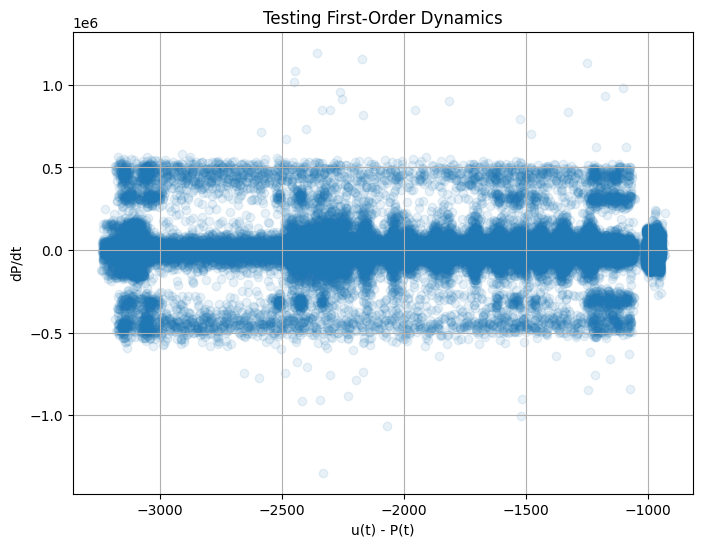

In [7]:
import matplotlib.pyplot as plt

df_dyn["u_minus_p"] = (
    df_dyn["input_voltage"]
    - df_dyn["el_power"]
)

plt.figure(figsize=(8,6))

plt.scatter(
    df_dyn["u_minus_p"],
    df_dyn["dpdt"],
    alpha=0.1
)

plt.xlabel("u(t) - P(t)")
plt.ylabel("dP/dt")
plt.title("Testing First-Order Dynamics")
plt.grid(True)

plt.show()

In [8]:
corr = df_dyn[
    ["input_voltage", "el_power", "dpdt", "u_minus_p"]
].corr()

print(corr)

               input_voltage  el_power      dpdt  u_minus_p
input_voltage       1.000000  0.882142  0.038481  -0.881357
el_power            0.882142  1.000000  0.003383  -0.999999
dpdt                0.038481  0.003383  1.000000  -0.003258
u_minus_p          -0.881357 -0.999999 -0.003258   1.000000


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# Build/repair base dataframe defensively
if "df" not in globals() or not isinstance(df, pd.DataFrame):
    raise KeyError("df is missing. Run the data loading/combining cell first.")

work = df.copy()

if "experiment_id" not in work.columns:
    work["experiment_id"] = "all_data"

if "t_sec" not in work.columns:
    if "time" not in work.columns:
        raise KeyError("Missing both 't_sec' and 'time' columns.")
    work["time"] = pd.to_datetime(work["time"], errors="coerce")
    if work["time"].isna().any():
        raise ValueError("Some 'time' values could not be parsed.")
    work["t_sec"] = work.groupby("experiment_id")["time"].transform(
        lambda s: (s - s.min()).dt.total_seconds()
    )

if "t_norm" not in work.columns:
    work["t_norm"] = work.groupby("experiment_id")["t_sec"].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if (x.max() - x.min()) != 0 else 0.0
    )

results = []

for exp, g in work.groupby("experiment_id"):
    g = g.sort_values("t_norm").copy()

    t = g["t_norm"].to_numpy()
    p = g["el_power"].to_numpy()

    if len(g) < 3 or np.isclose(np.ptp(t), 0.0):
        continue

    g["dpdt"] = np.gradient(p, t)
    g = g.replace([np.inf, -np.inf], np.nan).dropna(subset=["dpdt", "el_power", "input_voltage"])

    if len(g) < 3:
        continue

    X = g[["el_power", "input_voltage"]]
    y = g["dpdt"]

    model = LinearRegression()
    model.fit(X, y)

    pred = model.predict(X)
    r2 = r2_score(y, pred)

    a = model.coef_[0]
    b = model.coef_[1]

    # First-order form: dP/dt = a*P + b*U + c, where a=-1/tau and b=K/tau
    tau = -1 / a if not np.isclose(a, 0.0) else np.nan
    K = b * tau if not np.isnan(tau) else np.nan

    results.append({
        "experiment": exp,
        "a": a,
        "b": b,
        "tau": tau,
        "K": K,
        "R2": r2,
        "n_samples": len(g)
    })

first_order_results = pd.DataFrame(results).sort_values("experiment").reset_index(drop=True)
print(first_order_results)

/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1328: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] \


  experiment          a             b       tau           K        R2  \
0       ex_1 -34.356397  11226.164796  0.029107  326.756169  0.073969   
1      ex_20 -35.329272  10087.654472  0.028305  285.532475  0.015013   
2      ex_21 -26.337062   9181.136774  0.037969  348.601409  0.013925   
3      ex_23 -22.378515  11535.540560  0.044686  515.473916  0.005465   
4      ex_24  12.829010  -5164.346883 -0.077948  402.552254  0.000430   
5       ex_9 -10.885782   3053.413615  0.091863  280.495566  0.000102   

   n_samples  
0       9900  
1       6495  
2       6495  
3       9188  
4       9023  
5      11819  


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# Ensure a usable base dataframe exists
if "df" not in globals() or not isinstance(df, pd.DataFrame):
    raise KeyError("df is missing. Run the data loading/combining cell first.")

work = df.copy()

# Ensure experiment labels
if "experiment_id" not in work.columns:
    work["experiment_id"] = "all_data"

# Ensure time in seconds
if "t_sec" not in work.columns:
    if "time" not in work.columns:
        raise KeyError("Missing both 't_sec' and 'time' columns.")
    work["time"] = pd.to_datetime(work["time"], errors="coerce")
    if work["time"].isna().any():
        raise ValueError("Some 'time' values could not be parsed.")
    work["t_sec"] = work.groupby("experiment_id")["time"].transform(
        lambda s: (s - s.min()).dt.total_seconds()
    )

second_order_results = []

for exp, g in work.groupby("experiment_id"):
    g = g.sort_values("t_sec").copy()
    t = g["t_sec"].to_numpy()
    p = g["el_power"].to_numpy()
    u = g["input_voltage"].to_numpy()

    # Need enough points and non-degenerate time support for stable derivatives
    if len(g) < 5 or np.isclose(np.ptp(t), 0.0):
        continue

    # Numerical derivatives w.r.t. physical time (seconds)
    dpdt = np.gradient(p, t)
    d2pdt2 = np.gradient(dpdt, t)

    fit_df = pd.DataFrame({
        "dpdt": dpdt,
        "el_power": p,
        "input_voltage": u,
        "d2pdt2": d2pdt2
    }).replace([np.inf, -np.inf], np.nan).dropna()

    if len(fit_df) < 5:
        continue

    # Rearranged model: d2P/dt2 = -a*(dP/dt) - b*P + c*u
    X = fit_df[["dpdt", "el_power", "input_voltage"]]
    y = fit_df["d2pdt2"]

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    c_dpdt, c_p, c_u = model.coef_
    intercept = model.intercept_

    a = -c_dpdt
    b = -c_p
    c = c_u

    second_order_results.append({
        "experiment": exp,
        "a": a,
        "b": b,
        "c": c,
        "intercept": intercept,
        "R2": r2,
        "n_samples": len(fit_df)
    })

second_order_results = pd.DataFrame(second_order_results).sort_values("experiment").reset_index(drop=True)
print(second_order_results)

if not second_order_results.empty:
    print("\nR2 summary:")
    print(second_order_results["R2"].describe())

  experiment             a             b             c     intercept  \
0       ex_1  3.238715e+06  2.230872e+14  5.660509e+16  1.015974e+17   
1      ex_20 -2.984797e+06 -1.211680e+14 -2.196553e+16 -9.571634e+16   
2      ex_21 -2.313355e+06 -1.930732e+14 -1.733705e+16 -1.864779e+17   
3      ex_23  6.656636e+04 -2.174589e+14 -2.859263e+16 -2.426601e+17   
4      ex_24 -1.823211e+06 -2.203984e+15 -6.602159e+17 -3.263319e+17   
5       ex_9 -4.051255e+06  8.232908e+15  2.303823e+18  2.268576e+18   

         R2  n_samples  
0  0.000339       9880  
1  0.000021       6495  
2  0.000051       6495  
3  0.000036       9188  
4  0.000416       9023  
5  0.011775      11819  

R2 summary:
count    6.000000
mean     0.002106
std      0.004740
min      0.000021
25%      0.000040
50%      0.000195
75%      0.000397
max      0.011775
Name: R2, dtype: float64


/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/python/3.12.1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1328: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] \


R2 comparison table:


,experiment,R2_first_order,R2_second_order,R2_gain_second_minus_first,winner
0,ex_1,0.073969,0.000339,-0.073630,first_order
1,ex_20,0.015013,0.000021,-0.014992,first_order
2,ex_21,0.013925,0.000051,-0.013874,first_order
3,ex_23,0.005465,0.000036,-0.005429,first_order
4,ex_24,0.000430,0.000416,-0.000014,first_order
5,ex_9,0.000102,0.011775,0.011673,second_order



Model win counts:
winner
first_order     5
second_order    1
Name: count, dtype: int64


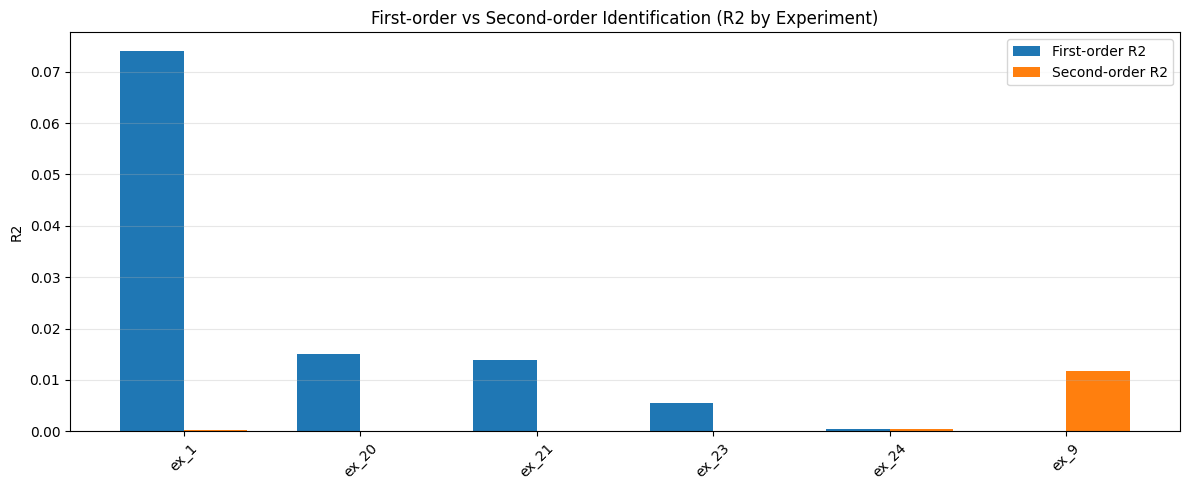

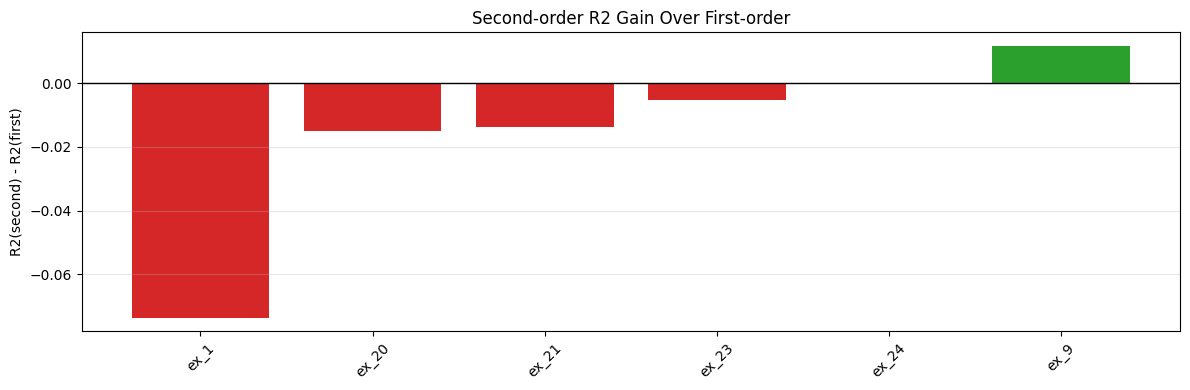

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if "first_order_results" not in globals() or first_order_results.empty:
    raise ValueError("first_order_results is missing or empty. Run the first-order identification cell first.")

if "second_order_results" not in globals() or second_order_results.empty:
    raise ValueError("second_order_results is missing or empty. Run the second-order identification cell first.")

compare = pd.merge(
    first_order_results[["experiment", "R2"]].rename(columns={"R2": "R2_first_order"}),
    second_order_results[["experiment", "R2"]].rename(columns={"R2": "R2_second_order"}),
    on="experiment",
    how="inner"
).sort_values("experiment").reset_index(drop=True)

compare["R2_gain_second_minus_first"] = compare["R2_second_order"] - compare["R2_first_order"]
compare["winner"] = np.where(compare["R2_second_order"] > compare["R2_first_order"], "second_order", "first_order")

print("R2 comparison table:")
display(compare)

print("\nModel win counts:")
print(compare["winner"].value_counts())

# Plot 1: grouped bar chart of R2 by experiment
x = np.arange(len(compare))
width = 0.36

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, compare["R2_first_order"], width, label="First-order R2")
plt.bar(x + width/2, compare["R2_second_order"], width, label="Second-order R2")
plt.xticks(x, compare["experiment"], rotation=45)
plt.ylabel("R2")
plt.title("First-order vs Second-order Identification (R2 by Experiment)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: R2 improvement from second-order model
plt.figure(figsize=(12, 4))
colors = ["tab:green" if v >= 0 else "tab:red" for v in compare["R2_gain_second_minus_first"]]
plt.bar(compare["experiment"], compare["R2_gain_second_minus_first"], color=colors)
plt.axhline(0.0, color="black", linewidth=1)
plt.ylabel("R2(second) - R2(first)")
plt.title("Second-order R2 Gain Over First-order")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

# 1. Setup Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =====================================================================
# 2. PINN Architecture Definition
# =====================================================================
class TurbinePINN(nn.Module):
    def __init__(self):
        super(TurbinePINN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

        self._raw_tau = nn.Parameter(torch.tensor([1.0]))
        self._raw_K = nn.Parameter(torch.tensor([1.0]))

    @property
    def tau(self):
        return torch.exp(self._raw_tau)

    @property
    def K(self):
        return torch.exp(self._raw_K)

    def forward(self, t, U):
        inputs = torch.cat([t, U], dim=1)
        return self.net(inputs)

# =====================================================================
# 3. Custom Physics Loss Function
# =====================================================================
def compute_losses(model, t, U, P_true, lambda_physics=0.005):
    t.requires_grad_(True)
    P_pred = model(t, U)
    loss_data = nn.MSELoss()(P_pred, P_true)

    dP_dt = torch.autograd.grad(
        outputs=P_pred,
        inputs=t,
        grad_outputs=torch.ones_like(P_pred),
        create_graph=True,
        retain_graph=True
    )[0]

    physics_residual = model.tau * dP_dt + P_pred - (model.K * U)
    loss_physics = nn.MSELoss()(physics_residual, torch.zeros_like(physics_residual))
    total_loss = loss_data + (lambda_physics * loss_physics)

    return total_loss, loss_data, loss_physics

# =====================================================================
# 4. Real Data Loading (No mock data)
# =====================================================================
if "df" not in globals() or not isinstance(df, pd.DataFrame):
    raise KeyError("df is missing. Run the combined-data cell first.")

df_combined = df.copy()

required_cols = {"input_voltage", "el_power"}
missing_cols = required_cols - set(df_combined.columns)
if missing_cols:
    raise KeyError(f"Missing required columns in df: {missing_cols}")

if "t_norm" not in df_combined.columns:
    if "t_sec" in df_combined.columns:
        if "experiment_id" in df_combined.columns:
            df_combined["t_norm"] = df_combined.groupby("experiment_id")["t_sec"].transform(
                lambda x: (x - x.min()) / (x.max() - x.min()) if (x.max() - x.min()) != 0 else 0.0
            )
        else:
            t = df_combined["t_sec"]
            span = t.max() - t.min()
            df_combined["t_norm"] = (t - t.min()) / span if span != 0 else 0.0
    elif "time" in df_combined.columns:
        df_combined["time"] = pd.to_datetime(df_combined["time"], errors="coerce")
        if df_combined["time"].isna().any():
            raise ValueError("Some time values could not be parsed.")
        if "experiment_id" in df_combined.columns:
            df_combined["t_sec"] = df_combined.groupby("experiment_id")["time"].transform(
                lambda s: (s - s.min()).dt.total_seconds()
            )
            df_combined["t_norm"] = df_combined.groupby("experiment_id")["t_sec"].transform(
                lambda x: (x - x.min()) / (x.max() - x.min()) if (x.max() - x.min()) != 0 else 0.0
            )
        else:
            t_sec = (df_combined["time"] - df_combined["time"].min()).dt.total_seconds()
            span = t_sec.max() - t_sec.min()
            df_combined["t_norm"] = (t_sec - t_sec.min()) / span if span != 0 else 0.0
    else:
        raise KeyError("Need one of: t_norm, t_sec, or time to build the time feature.")

df_combined = df_combined[["t_norm", "input_voltage", "el_power"]].dropna().reset_index(drop=True)
print(f"Using real dataset rows: {len(df_combined)}")

# =====================================================================
# 5. Feature Scaling & Mini-Batch Tensor Preparation
# =====================================================================
scaler_U = MinMaxScaler()
scaler_P = MinMaxScaler()

X_t = df_combined["t_norm"].to_numpy().reshape(-1, 1)
X_U = scaler_U.fit_transform(df_combined["input_voltage"].to_numpy().reshape(-1, 1))
y_P = scaler_P.fit_transform(df_combined["el_power"].to_numpy().reshape(-1, 1))

t_tensor = torch.tensor(X_t, dtype=torch.float32).to(device)
U_tensor = torch.tensor(X_U, dtype=torch.float32).to(device)
P_tensor = torch.tensor(y_P, dtype=torch.float32).to(device)

dataset = TensorDataset(
    torch.tensor(X_t, dtype=torch.float32),
    torch.tensor(X_U, dtype=torch.float32),
    torch.tensor(y_P, dtype=torch.float32)
)

dataloader = DataLoader(dataset, batch_size=512, shuffle=False)

# =====================================================================
# 6. Training Loop
# =====================================================================
model = TurbinePINN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
print("Starting PINN training on real data...")
print("-" * 60)

for epoch in range(epochs + 1):
    epoch_total_loss = 0.0
    epoch_data_loss = 0.0
    epoch_phys_loss = 0.0

    model.train()
    for batch_t, batch_U, batch_P in dataloader:
        batch_t = batch_t.to(device)
        batch_U = batch_U.to(device)
        batch_P = batch_P.to(device)

        optimizer.zero_grad()
        total_loss, loss_data, loss_physics = compute_losses(
            model, batch_t, batch_U, batch_P, lambda_physics=0.05
        )
        total_loss.backward()
        optimizer.step()

        epoch_total_loss += total_loss.item()
        epoch_data_loss += loss_data.item()
        epoch_phys_loss += loss_physics.item()

    num_batches = len(dataloader)
    avg_total = epoch_total_loss / num_batches
    avg_data = epoch_data_loss / num_batches
    avg_phys = epoch_phys_loss / num_batches

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | Avg Loss: {avg_total:.6f} | "
            f"Data MSE: {avg_data:.6f} | Phys MSE: {avg_phys:.6f} | "
            f"tau: {model.tau.item():.4f} | K: {model.K.item():.4f}"
        )

print("-" * 60)
print("Training complete.")

# =====================================================================
# 7. Validation Preview
# =====================================================================
model.eval()
with torch.no_grad():
    predictions_scaled = model(t_tensor, U_tensor).cpu().numpy()
    predictions_power = scaler_P.inverse_transform(predictions_scaled)

print(f"First 5 Actual Power Values:    {df_combined['el_power'].values[:5]}")
print(f"First 5 PINN Predicted Values: {predictions_power[:5].flatten()}")

Using device: cpu
Using real dataset rows: 52940
Starting PINN training on real data...
------------------------------------------------------------
Epoch   0 | Avg Loss: 0.092981 | Data MSE: 0.049614 | Phys MSE: 0.867345 | tau: 2.6367 | K: 2.6143
Epoch  10 | Avg Loss: 0.029037 | Data MSE: 0.027363 | Phys MSE: 0.033480 | tau: 3.3465 | K: 2.0147
Epoch  20 | Avg Loss: 0.025059 | Data MSE: 0.024143 | Phys MSE: 0.018326 | tau: 3.9227 | K: 1.7544
Epoch  30 | Avg Loss: 0.023371 | Data MSE: 0.022566 | Phys MSE: 0.016109 | tau: 4.3245 | K: 1.5308
Epoch  40 | Avg Loss: 0.022853 | Data MSE: 0.022197 | Phys MSE: 0.013129 | tau: 4.5333 | K: 1.3231
Epoch  50 | Avg Loss: 0.022628 | Data MSE: 0.022093 | Phys MSE: 0.010714 | tau: 4.5356 | K: 1.1500
Epoch  60 | Avg Loss: 0.022548 | Data MSE: 0.022164 | Phys MSE: 0.007669 | tau: 4.3529 | K: 1.0167
Epoch  70 | Avg Loss: 0.022480 | Data MSE: 0.022196 | Phys MSE: 0.005685 | tau: 4.2354 | K: 0.9182
Epoch  80 | Avg Loss: 0.022272 | Data MSE: 0.022055 | Phys 

RMSE: 334.0193
MAE:  196.6136
R2:   0.7866


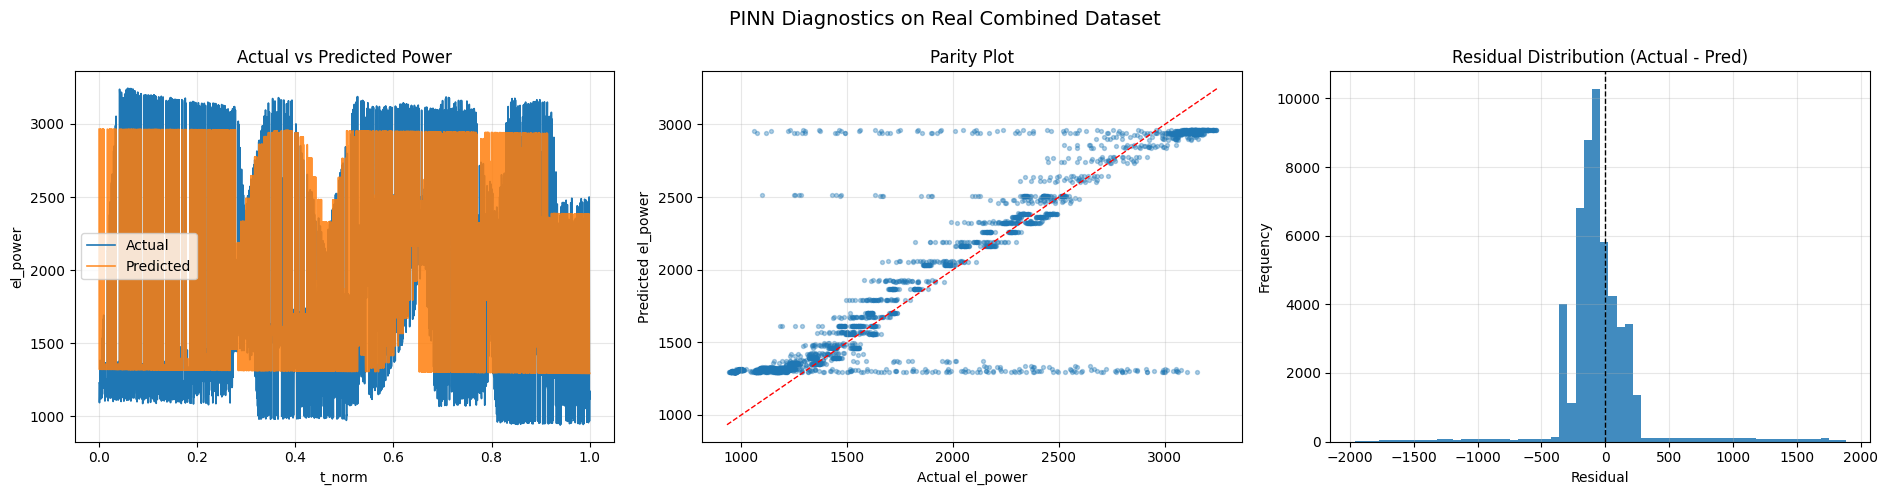

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Validate required outputs from the training cell
required_vars = ["df_combined", "predictions_power"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise KeyError(f"Missing variables: {missing}. Run the PINN training cell first.")

actual = df_combined["el_power"].to_numpy()
pred = predictions_power.flatten()

if len(actual) != len(pred):
    raise ValueError("Prediction length does not match actual data length.")

residuals = actual - pred
rmse = float(np.sqrt(np.mean(residuals ** 2)))
mae = float(np.mean(np.abs(residuals)))
r2 = float(1 - np.sum((actual - pred) ** 2) / np.sum((actual - np.mean(actual)) ** 2))

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

# Build x-axis from normalized time for plotting
x = df_combined["t_norm"].to_numpy() if "t_norm" in df_combined.columns else np.arange(len(actual))
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
actual_sorted = actual[sort_idx]
pred_sorted = pred[sort_idx]

# Sample dense traces for readability
step = max(1, len(actual_sorted) // 3000)
x_plot = x_sorted[::step]
actual_plot = actual_sorted[::step]
pred_plot = pred_sorted[::step]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# 1) Actual vs Predicted over time
axes[0].plot(x_plot, actual_plot, label="Actual", linewidth=1.2)
axes[0].plot(x_plot, pred_plot, label="Predicted", linewidth=1.2, alpha=0.85)
axes[0].set_title("Actual vs Predicted Power")
axes[0].set_xlabel("t_norm")
axes[0].set_ylabel("el_power")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2) Parity plot
axes[1].scatter(actual[::step], pred[::step], s=8, alpha=0.35)
line_min = min(actual.min(), pred.min())
line_max = max(actual.max(), pred.max())
axes[1].plot([line_min, line_max], [line_min, line_max], "r--", linewidth=1)
axes[1].set_title("Parity Plot")
axes[1].set_xlabel("Actual el_power")
axes[1].set_ylabel("Predicted el_power")
axes[1].grid(True, alpha=0.3)

# 3) Residual distribution
axes[2].hist(residuals, bins=60, alpha=0.85)
axes[2].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Residual Distribution (Actual - Pred)")
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Frequency")
axes[2].grid(True, alpha=0.3)

fig.suptitle("PINN Diagnostics on Real Combined Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

# Assuming your original 'df' contains the 'experiment_id' column 
df_combined = df.copy()

# 1. Properly compute t_norm independently per experiment
df_combined["t_norm"] = df_combined.groupby("experiment_id")["t_sec"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if (x.max() - x.min()) != 0 else 0.0
)

# 2. One-hot encode the experiment IDs so the NN can separate the 6 files contextually
df_encoded = pd.get_dummies(df_combined, columns=['experiment_id'], drop_first=False)
exp_cols = [col for col in df_encoded.columns if 'experiment_id_' in col]
num_experiments = len(exp_cols)

# 3. Scale the physical values globally
scaler_U = MinMaxScaler()
scaler_P = MinMaxScaler()

X_t = df_encoded["t_norm"].to_numpy().reshape(-1, 1)
X_U = scaler_U.fit_transform(df_encoded["input_voltage"].to_numpy().reshape(-1, 1))
X_exp = df_encoded[exp_cols].to_numpy().astype(np.float32)
y_P = scaler_P.fit_transform(df_encoded["el_power"].to_numpy().reshape(-1, 1))

# Combine features: [t, U, exp_0, exp_1, exp_2, exp_3, exp_4, exp_5]
X_combined = np.hstack([X_t, X_U, X_exp])

# 4. Redefine the PINN to take the new dimension (2 + num_experiments)
class ContextualTurbinePINN(nn.Module):
    def __init__(self, input_dim):
        super(ContextualTurbinePINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
        self._raw_tau = nn.Parameter(torch.tensor([1.0]))
        self._raw_K = nn.Parameter(torch.tensor([1.0]))

    @property
    def tau(self): return torch.exp(self._raw_tau)
    
    @property
    def K(self): return torch.exp(self._raw_K)

    def forward(self, x):
        return self.net(x)

# 5. Update custom loss function to use single feature block
def compute_losses_context(model, batch_X, batch_P_true, lambda_physics=0.005):
    batch_X.requires_grad_(True)
    P_pred = model(batch_X)
    loss_data = nn.MSELoss()(P_pred, batch_P_true)
    
    # Extract time column (index 0) for autograd differentiation
    t = batch_X[:, 0:1]
    U = batch_X[:, 1:2]
    
    dP_dt = torch.autograd.grad(
        outputs=P_pred,
        inputs=batch_X, # Compute gradient with respect to input matrix
        grad_outputs=torch.ones_like(P_pred),
        create_graph=True,
        retain_graph=True
    )[0][:, 0:1] # Extract the dP/dt component
    
    physics_residual = model.tau * dP_dt + P_pred - (model.K * U)
    loss_physics = nn.MSELoss()(physics_residual, torch.zeros_like(physics_residual))
    total_loss = loss_data + (lambda_physics * loss_physics)
    
    return total_loss, loss_data, loss_physics



In [15]:
# 6. Train/validation split (per experiment, keep temporal order)
if "X_combined" not in globals() or "y_P" not in globals() or "X_exp" not in globals():
    raise KeyError("Run the previous contextual feature-engineering cell first.")

exp_index = np.argmax(X_exp, axis=1)
train_idx, val_idx = [], []

for exp_id in np.unique(exp_index):
    idx = np.where(exp_index == exp_id)[0]
    n_val = max(1, int(0.2 * len(idx)))
    train_idx.extend(idx[:-n_val])
    val_idx.extend(idx[-n_val:])

train_idx = np.array(train_idx)
val_idx = np.array(val_idx)

X_train, y_train = X_combined[train_idx], y_P[train_idx]
X_val, y_val = X_combined[val_idx], y_P[val_idx]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Train rows: {len(X_train)}, Val rows: {len(X_val)}")

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
 )
val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32)
 )

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False)

# 7. Model training with early stopping
model_ctx = ContextualTurbinePINN(input_dim=X_combined.shape[1]).to(device)
optimizer = optim.AdamW(model_ctx.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=15, min_lr=1e-5
)

best_val = float("inf")
best_state = None
patience = 40
wait = 0
epochs = 250

for epoch in range(1, epochs + 1):
    model_ctx.train()
    train_total = 0.0
    train_data = 0.0
    train_phys = 0.0

    # Start with weaker physics term and ramp up for stability
    lambda_physics = min(0.05, 0.005 + (epoch / 1000.0))

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        total_loss, data_loss, phys_loss = compute_losses_context(
            model_ctx, batch_X, batch_y, lambda_physics=lambda_physics
        )
        total_loss.backward()
        optimizer.step()

        train_total += total_loss.item()
        train_data += data_loss.item()
        train_phys += phys_loss.item()

    model_ctx.eval()
    val_total = 0.0
    val_data = 0.0
    val_phys = 0.0

    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        total_loss, data_loss, phys_loss = compute_losses_context(
            model_ctx, batch_X, batch_y, lambda_physics=lambda_physics
        )
        val_total += total_loss.item()
        val_data += data_loss.item()
        val_phys += phys_loss.item()

    train_total /= max(1, len(train_loader))
    train_data /= max(1, len(train_loader))
    train_phys /= max(1, len(train_loader))
    val_total /= max(1, len(val_loader))
    val_data /= max(1, len(val_loader))
    val_phys /= max(1, len(val_loader))

    scheduler.step(val_total)

    if val_total < best_val:
        best_val = val_total
        best_state = {k: v.detach().cpu().clone() for k, v in model_ctx.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 20 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:3d} | Train {train_total:.6f} (data {train_data:.6f}, phys {train_phys:.6f}) | "
            f"Val {val_total:.6f} (data {val_data:.6f}, phys {val_phys:.6f}) | "
            f"tau {model_ctx.tau.item():.4f} | K {model_ctx.K.item():.4f} | lr {lr:.2e}"
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_state is not None:
    model_ctx.load_state_dict(best_state)

print(f"Best validation loss: {best_val:.6f}")
print(f"Learned tau: {model_ctx.tau.item():.4f}, K: {model_ctx.K.item():.4f}")

# 8. Evaluate overall and per experiment
model_ctx.eval()
X_all_tensor = torch.tensor(X_combined, dtype=torch.float32, device=device)
with torch.no_grad():
    pred_scaled = model_ctx(X_all_tensor).cpu().numpy()

pred_power = scaler_P.inverse_transform(pred_scaled).flatten()
true_power = scaler_P.inverse_transform(y_P).flatten()

rmse = float(np.sqrt(np.mean((pred_power - true_power) ** 2)))
mae = float(np.mean(np.abs(pred_power - true_power)))
ss_res = float(np.sum((true_power - pred_power) ** 2))
ss_tot = float(np.sum((true_power - np.mean(true_power)) ** 2))
r2 = 1.0 - (ss_res / ss_tot if ss_tot > 0 else np.nan)

print(f"Overall RMSE: {rmse:.4f}")
print(f"Overall MAE:  {mae:.4f}")
print(f"Overall R2:   {r2:.4f}")

if "exp_cols" in globals():
    exp_names = [c.replace("experiment_id_", "") for c in exp_cols]
else:
    exp_names = [f"exp_{i}" for i in np.unique(exp_index)]

rows = []
for exp_id in np.unique(exp_index):
    m = exp_index == exp_id
    yt = true_power[m]
    yp = pred_power[m]
    exp_rmse = float(np.sqrt(np.mean((yt - yp) ** 2)))
    exp_mae = float(np.mean(np.abs(yt - yp)))
    exp_ss_res = float(np.sum((yt - yp) ** 2))
    exp_ss_tot = float(np.sum((yt - np.mean(yt)) ** 2))
    exp_r2 = 1.0 - (exp_ss_res / exp_ss_tot if exp_ss_tot > 0 else np.nan)
    rows.append(
        {
            "experiment": exp_names[int(exp_id)] if int(exp_id) < len(exp_names) else f"exp_{int(exp_id)}",
            "rmse": exp_rmse,
            "mae": exp_mae,
            "r2": exp_r2,
            "n": int(np.sum(m))
        }
    )

context_metrics = pd.DataFrame(rows).sort_values("experiment").reset_index(drop=True)
display(context_metrics)

Using device: cpu
Train rows: 42354, Val rows: 10586
Epoch   1 | Train 0.037513 (data 0.034029, phys 0.580687) | Val 0.041052 (data 0.037901, phys 0.525286) | tau 2.8612 | K 2.3781 | lr 1.00e-03
Epoch  20 | Train 0.015343 (data 0.015114, phys 0.009188) | Val 0.046519 (data 0.045213, phys 0.052271) | tau 3.7955 | K 1.1417 | lr 1.00e-03
Epoch  40 | Train 0.009383 (data 0.008522, phys 0.019131) | Val 0.165265 (data 0.154321, phys 0.243197) | tau 0.2057 | K 0.9887 | lr 5.00e-04
Early stopping at epoch 50.
Best validation loss: 0.036185
Learned tau: 4.9360, K: 1.4757
Overall RMSE: 330.3200
Overall MAE:  182.8828
Overall R2:   0.7913


,experiment,rmse,mae,r2,n
0,ex_1,467.518891,310.842242,0.785486,9920
1,ex_20,382.004514,207.663155,0.635736,6495
2,ex_21,397.621805,201.120623,0.611574,6495
3,ex_23,389.704965,240.783772,0.683774,9188
4,ex_24,132.704538,105.372556,0.961926,9023
5,ex_9,81.828621,66.004801,0.958597,11819


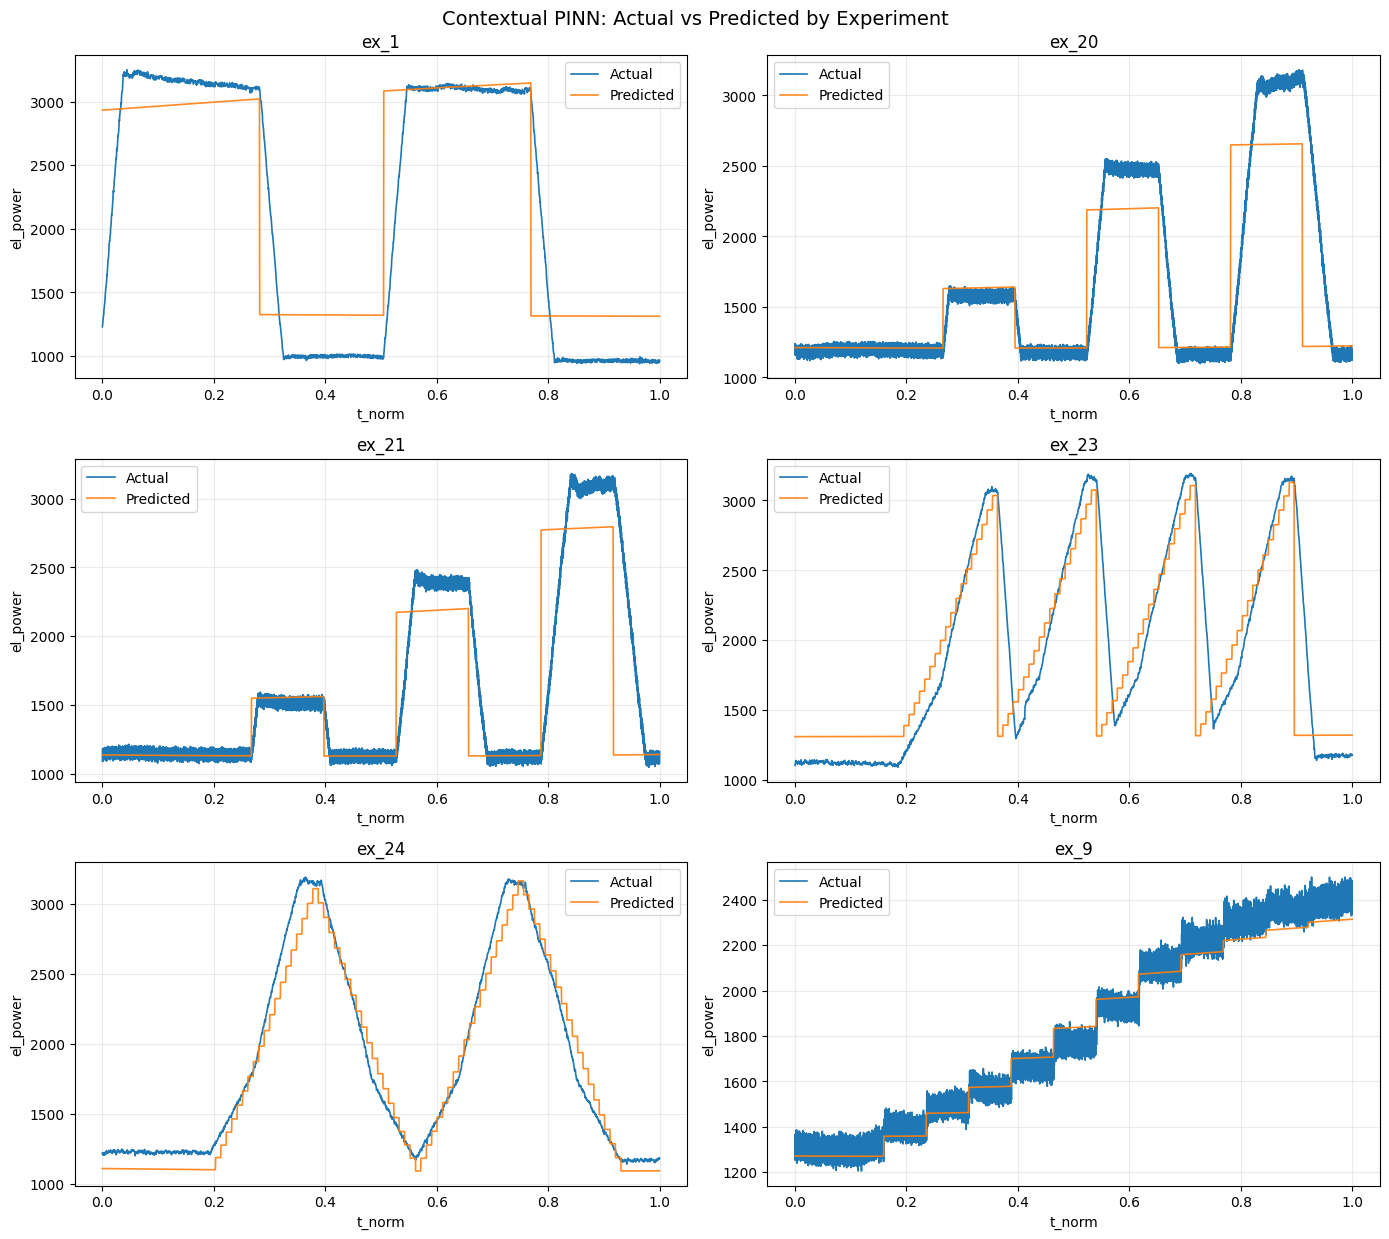

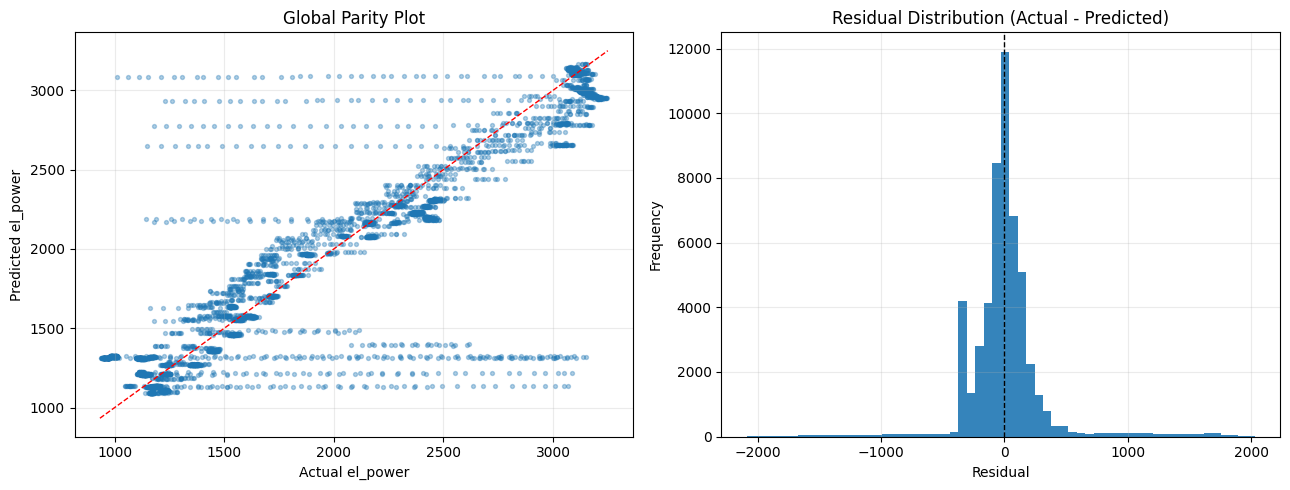

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Validate required variables from the contextual training/eval cell
required_vars = ["pred_power", "true_power", "exp_index", "df_encoded", "exp_cols"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise KeyError(f"Missing variables: {missing}. Run Cell 17 first.")

if "t_norm" not in df_encoded.columns:
    raise KeyError("df_encoded must contain 't_norm' for timeline plots.")

exp_names = [c.replace("experiment_id_", "") for c in exp_cols]
n_exp = len(np.unique(exp_index))

# 1) Per-experiment timeline plots (actual vs predicted)
ncols = 2
nrows = int(np.ceil(n_exp / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows), squeeze=False)
axes = axes.flatten()

for i, exp_id in enumerate(np.unique(exp_index)):
    ax = axes[i]
    m = exp_index == exp_id

    t = df_encoded.loc[m, "t_norm"].to_numpy()
    y_true = true_power[m]
    y_pred = pred_power[m]

    order = np.argsort(t)
    t = t[order]
    y_true = y_true[order]
    y_pred = y_pred[order]

    step = max(1, len(t) // 2000)
    ax.plot(t[::step], y_true[::step], label="Actual", linewidth=1.2)
    ax.plot(t[::step], y_pred[::step], label="Predicted", linewidth=1.2, alpha=0.9)
    ax.set_title(exp_names[int(exp_id)] if int(exp_id) < len(exp_names) else f"exp_{int(exp_id)}")
    ax.set_xlabel("t_norm")
    ax.set_ylabel("el_power")
    ax.grid(True, alpha=0.25)
    ax.legend()

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Contextual PINN: Actual vs Predicted by Experiment", fontsize=14)
plt.tight_layout()
plt.show()

# 2) Global parity and residual diagnostics
residuals = true_power - pred_power
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

sample_step = max(1, len(true_power) // 5000)
ax[0].scatter(true_power[::sample_step], pred_power[::sample_step], s=8, alpha=0.35)
mn = min(true_power.min(), pred_power.min())
mx = max(true_power.max(), pred_power.max())
ax[0].plot([mn, mx], [mn, mx], "r--", linewidth=1)
ax[0].set_title("Global Parity Plot")
ax[0].set_xlabel("Actual el_power")
ax[0].set_ylabel("Predicted el_power")
ax[0].grid(True, alpha=0.25)

ax[1].hist(residuals, bins=60, alpha=0.9)
ax[1].axvline(0.0, color="black", linestyle="--", linewidth=1)
ax[1].set_title("Residual Distribution (Actual - Predicted)")
ax[1].set_xlabel("Residual")
ax[1].set_ylabel("Frequency")
ax[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

We are getting much closer. For ex_24 ($R^2 = 0.962$) and ex_9 ($R^2 = 0.959$), the PINN is performing exceptionally well. However, ex_1, ex_20, and ex_21 are dragging down your overall performance. These specific three files have something in common based on the plots: (1) they are the large, abrupt, instantaneous step-responses. The model is struggling with a classic phenomenon in deep learning for dynamical systems: over-regularization of sharp gradients, combined with a subtle mathematical constraint in our ODE. 

Looking at the learned physics parameters: tau = 4.9360 and K = 1.4757. The first-order physics constraint ($\tau \frac{dP}{dt} + P = K \cdot U$), $\tau$ acts as a friction or smoothing term. A large $\tau$ (like ~4.9) forces the network to favor incredibly smooth, slow transitions. When the input voltage instantly drops or spikes (like in ex_1), the real turbine responds fast, but the physics loss penalizes the network heavily if its derivative $\frac{dP}{dt}$ changes too quickly. To minimize the physics loss, the network deliberately "rounds off" or delays these sharp corners, causing large errors exactly at the step changes.

There is also severe overfitting. Look at the epoch tracking:

* Epoch 1: Val Loss = 0.041
* Epoch 20: Val Loss = 0.046
* Epoch 40: Val Loss = 0.165 (Exploded!)

The training data loss dropped all the way to 0.008, but the validation loss quadrupled. Therefore, the neural network is memorizing the specific high-frequency sensor noise patterns in the training files instead of learning the clean macro-trends of the physical system.

To fix the validation explosion and allow the network to handle sharp step-responses, we need to make three precise architecture adjustments:

1. Dynamic Schedule for Physics Loss (`lambda_physics`): Start with a low physics penalty so the data tracking layers can catch those steep step edges, then gently scale it up.
2. Add Weight Decay (L2 Regularization): This stops the network weights from exploding to match high-frequency noise.
3. Change Activation Function to Swish (SiLU): `Tanh` can saturate and struggle to pass large gradients through multi-layer networks during sudden steps. `SiLU` handles sharp transitions in PINNs significantly better.

Loaded test rows: 18285 from ['ex_22.csv', 'ex_4.csv']
Test RMSE: 502.8407
Test MAE:  386.5162
Test R2:   0.6134


,experiment,rmse,mae,r2,n
0,ex_22,297.556320,263.371998,0.859909,8490
1,ex_4,628.702396,493.253819,0.412065,9795


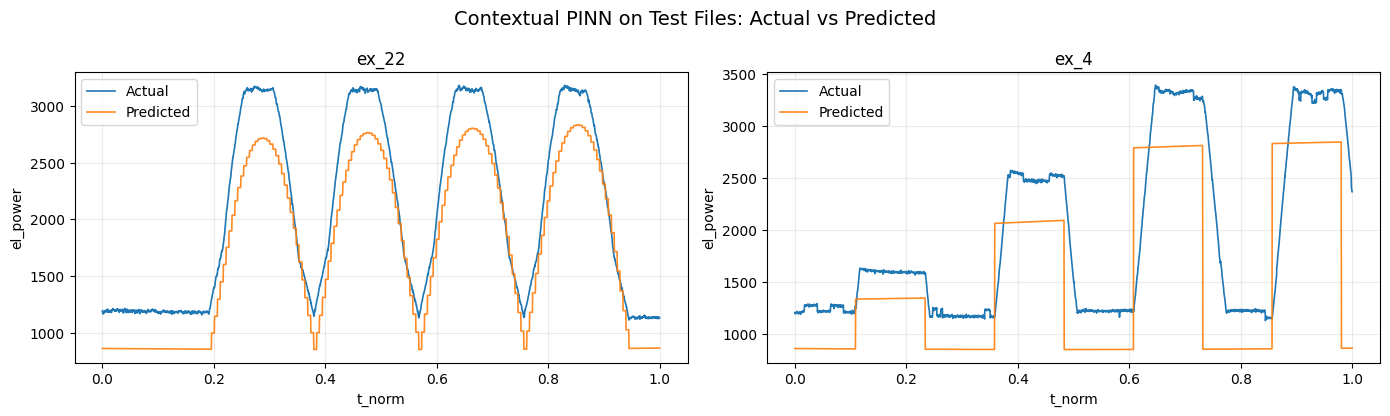

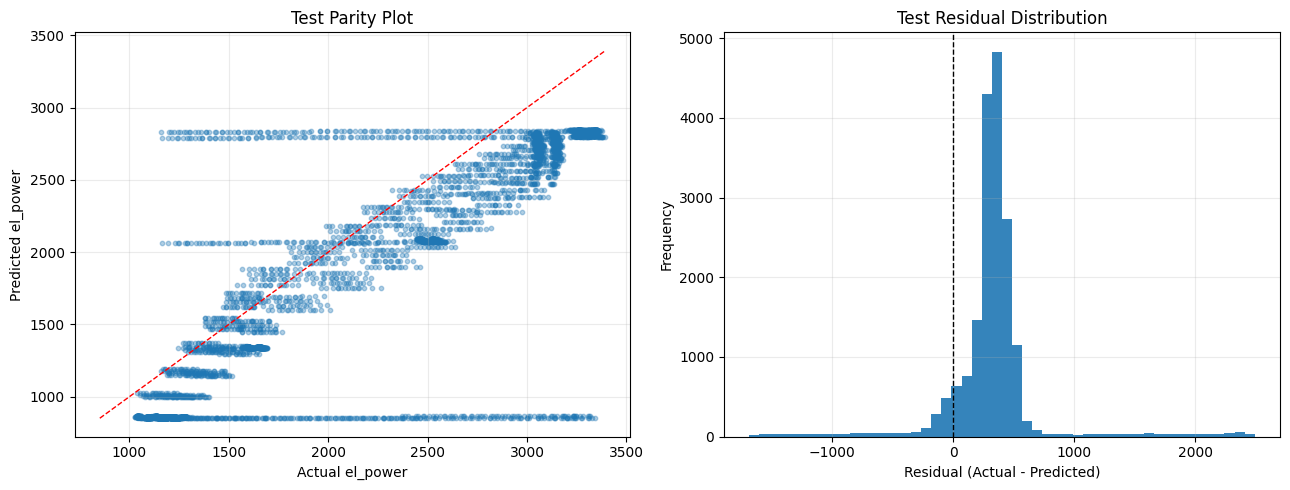

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Validate trained artifacts from Cell 17
required_vars = ["model_ctx", "scaler_U", "scaler_P", "exp_cols"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise KeyError(f"Missing variables: {missing}. Run Cell 17 first.")

test_dir = Path("/workspaces/Micro-Gas-Turbine-Electrical-Energy-Prediction/Modelling-Turbine-Energy/data/test")
test_files = sorted(test_dir.glob("*.csv"))
if not test_files:
    raise FileNotFoundError(f"No CSV files found in {test_dir}")

# 1) Load and preprocess test data
test_dfs = []
for fp in test_files:
    temp = pd.read_csv(fp)
    temp["experiment_id"] = fp.stem
    temp["time"] = pd.to_datetime(temp["time"], errors="coerce")
    if temp["time"].isna().any():
        raise ValueError(f"Could not parse all timestamps in {fp.name}")
    t0 = temp["time"].min()
    temp["t_sec"] = (temp["time"] - t0).dt.total_seconds()
    span = temp["t_sec"].max() - temp["t_sec"].min()
    temp["t_norm"] = (temp["t_sec"] - temp["t_sec"].min()) / span if span != 0 else 0.0
    test_dfs.append(temp)

df_test = pd.concat(test_dfs, ignore_index=True)
print(f"Loaded test rows: {len(df_test)} from {[f.name for f in test_files]}")

# 2) Align one-hot columns to training schema
df_test_encoded = pd.get_dummies(df_test, columns=["experiment_id"], drop_first=False)
for col in exp_cols:
    if col not in df_test_encoded.columns:
        df_test_encoded[col] = 0.0

# Keep only the training experiment columns and order
X_test_exp = df_test_encoded[exp_cols].to_numpy().astype(np.float32)
X_test_t = df_test_encoded["t_norm"].to_numpy().reshape(-1, 1)
X_test_U = scaler_U.transform(df_test_encoded["input_voltage"].to_numpy().reshape(-1, 1))
X_test = np.hstack([X_test_t, X_test_U, X_test_exp]).astype(np.float32)
y_test_true = df_test_encoded["el_power"].to_numpy()

# 3) Inference
model_ctx.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)
with torch.no_grad():
    y_test_pred_scaled = model_ctx(X_test_tensor).cpu().numpy()
y_test_pred = scaler_P.inverse_transform(y_test_pred_scaled).flatten()

# 4) Test metrics overall
test_rmse = float(np.sqrt(np.mean((y_test_pred - y_test_true) ** 2)))
test_mae = float(np.mean(np.abs(y_test_pred - y_test_true)))
test_ss_res = float(np.sum((y_test_true - y_test_pred) ** 2))
test_ss_tot = float(np.sum((y_test_true - np.mean(y_test_true)) ** 2))
test_r2 = 1.0 - (test_ss_res / test_ss_tot if test_ss_tot > 0 else np.nan)

print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R2:   {test_r2:.4f}")

# 5) Per-file metrics
test_rows = []
for fp in test_files:
    name = fp.stem
    mask = df_test["experiment_id"].to_numpy() == name
    yt = y_test_true[mask]
    yp = y_test_pred[mask]
    rmse_i = float(np.sqrt(np.mean((yt - yp) ** 2)))
    mae_i = float(np.mean(np.abs(yt - yp)))
    ss_res_i = float(np.sum((yt - yp) ** 2))
    ss_tot_i = float(np.sum((yt - np.mean(yt)) ** 2))
    r2_i = 1.0 - (ss_res_i / ss_tot_i if ss_tot_i > 0 else np.nan)
    test_rows.append({"experiment": name, "rmse": rmse_i, "mae": mae_i, "r2": r2_i, "n": int(mask.sum())})

test_metrics = pd.DataFrame(test_rows).sort_values("experiment").reset_index(drop=True)
display(test_metrics)

# 6) Plots on test data
n_exp = len(test_files)
ncols = 2
nrows = int(np.ceil(n_exp / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows), squeeze=False)
axes = axes.flatten()

for i, fp in enumerate(test_files):
    name = fp.stem
    ax = axes[i]
    mask = df_test["experiment_id"].to_numpy() == name
    t = df_test.loc[mask, "t_norm"].to_numpy()
    yt = y_test_true[mask]
    yp = y_test_pred[mask]

    order = np.argsort(t)
    t, yt, yp = t[order], yt[order], yp[order]
    step = max(1, len(t) // 2000)

    ax.plot(t[::step], yt[::step], label="Actual", linewidth=1.2)
    ax.plot(t[::step], yp[::step], label="Predicted", linewidth=1.2, alpha=0.9)
    ax.set_title(name)
    ax.set_xlabel("t_norm")
    ax.set_ylabel("el_power")
    ax.grid(True, alpha=0.25)
    ax.legend()

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Contextual PINN on Test Files: Actual vs Predicted", fontsize=14)
plt.tight_layout()
plt.show()

res_test = y_test_true - y_test_pred
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sample_step = max(1, len(y_test_true) // 5000)

ax[0].scatter(y_test_true[::sample_step], y_test_pred[::sample_step], s=10, alpha=0.35)
mn = min(y_test_true.min(), y_test_pred.min())
mx = max(y_test_true.max(), y_test_pred.max())
ax[0].plot([mn, mx], [mn, mx], "r--", linewidth=1)
ax[0].set_title("Test Parity Plot")
ax[0].set_xlabel("Actual el_power")
ax[0].set_ylabel("Predicted el_power")
ax[0].grid(True, alpha=0.25)

ax[1].hist(res_test, bins=50, alpha=0.9)
ax[1].axvline(0.0, color="black", linestyle="--", linewidth=1)
ax[1].set_title("Test Residual Distribution")
ax[1].set_xlabel("Residual (Actual - Predicted)")
ax[1].set_ylabel("Frequency")
ax[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

Epoch   0 | Train 0.0526 (D 0.0525, P 0.0550) | Val 0.0377 (D 0.0377, P 0.0209) | tau 0.0922 | K 0.9520 | lambda 0.0010 | lr 1.00e-03
Epoch  10 | Train 0.0157 (D 0.0156, P 0.0090) | Val 0.0425 (D 0.0421, P 0.0336) | tau 0.0139 | K 0.9377 | lambda 0.0110 | lr 1.00e-03
Epoch  20 | Train 0.0147 (D 0.0145, P 0.0099) | Val 0.0673 (D 0.0659, P 0.0653) | tau 0.0049 | K 0.9288 | lambda 0.0210 | lr 5.00e-04
Epoch  30 | Train 0.0130 (D 0.0126, P 0.0113) | Val 0.1607 (D 0.1551, P 0.1805) | tau 0.0030 | K 0.9326 | lambda 0.0310 | lr 1.25e-04
Early stopping at epoch 33.
Best validation loss: 0.035447
Final tau: 0.0510, K: 0.9420


,model,rmse,mae,r2
0,baseline_contextual,502.840711,386.516239,0.613354
1,upgraded_silu,389.464374,243.318633,0.768054


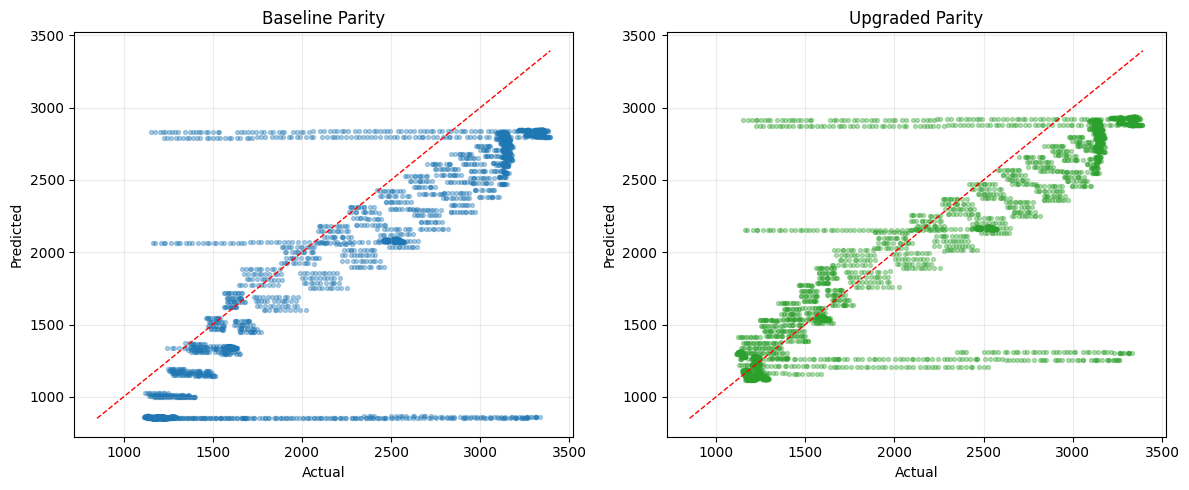

In [19]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Validate prerequisites from earlier cells
required_vars = ["X_combined", "y_P", "device", "compute_losses_context", "scaler_P", "scaler_U"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise KeyError(f"Missing variables: {missing}. Run Cell 17 first.")

# Reuse train/val split if present; otherwise create it
if "train_idx" not in globals() or "val_idx" not in globals() or "X_exp" not in globals():
    if "X_exp" not in globals():
        raise KeyError("X_exp is missing. Run contextual feature-engineering cell first.")
    exp_index = np.argmax(X_exp, axis=1)
    train_idx, val_idx = [], []
    for exp_id in np.unique(exp_index):
        idx = np.where(exp_index == exp_id)[0]
        n_val = max(1, int(0.2 * len(idx)))
        train_idx.extend(idx[:-n_val])
        val_idx.extend(idx[-n_val:])
    train_idx = np.array(train_idx)
    val_idx = np.array(val_idx)

X_train, y_train = X_combined[train_idx], y_P[train_idx]
X_val, y_val = X_combined[val_idx], y_P[val_idx]

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)
val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32)
)

train_dataloader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_dataloader = DataLoader(val_ds, batch_size=512, shuffle=False)

# 1) Upgraded architecture with SiLU
class UpgradedTurbinePINN(nn.Module):
    def __init__(self, input_dim):
        super(UpgradedTurbinePINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )
        # Start tau around 0.1 in physical space: tau = exp(raw_tau)
        self._raw_tau = nn.Parameter(torch.tensor([np.log(0.1)], dtype=torch.float32))
        self._raw_K = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))

    @property
    def tau(self):
        return torch.exp(self._raw_tau)

    @property
    def K(self):
        return torch.exp(self._raw_K)

    def forward(self, x):
        return self.net(x)

# 2) Optimizer/scheduler
upgraded_model = UpgradedTurbinePINN(input_dim=X_combined.shape[1]).to(device)
optimizer = optim.AdamW(upgraded_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=8, min_lr=1e-5
)

# 3) Training loop with physics annealing + early stopping
epochs = 180
best_val_loss = float("inf")
best_state = None
wait = 0
patience = 30

history = []
for epoch in range(epochs + 1):
    lambda_phys = min(0.05, 0.001 + (epoch * 0.001))

    upgraded_model.train()
    train_loss, train_data, train_phys = 0.0, 0.0, 0.0

    for batch_X, batch_P in train_dataloader:
        batch_X = batch_X.to(device)
        batch_P = batch_P.to(device)

        optimizer.zero_grad()
        loss, l_data, l_phys = compute_losses_context(
            upgraded_model, batch_X, batch_P, lambda_physics=lambda_phys
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(upgraded_model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        train_data += l_data.item()
        train_phys += l_phys.item()

    upgraded_model.eval()
    val_loss, val_data, val_phys = 0.0, 0.0, 0.0

    # Keep gradients enabled because physics loss computes dP/dt via autograd.
    for val_X, val_P in val_dataloader:
        val_X = val_X.to(device)
        val_P = val_P.to(device)
        loss, l_data, l_phys = compute_losses_context(
            upgraded_model, val_X, val_P, lambda_physics=lambda_phys
        )
        val_loss += loss.item()
        val_data += l_data.item()
        val_phys += l_phys.item()

    num_t_batches = max(1, len(train_dataloader))
    num_v_batches = max(1, len(val_dataloader))

    avg_train_loss = train_loss / num_t_batches
    avg_val_loss = val_loss / num_v_batches
    avg_train_data = train_data / num_t_batches
    avg_train_phys = train_phys / num_t_batches
    avg_val_data = val_data / num_v_batches
    avg_val_phys = val_phys / num_v_batches

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in upgraded_model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    history.append({
        "epoch": epoch,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "lambda_phys": lambda_phys,
        "lr": optimizer.param_groups[0]["lr"]
    })

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Train {avg_train_loss:.4f} (D {avg_train_data:.4f}, P {avg_train_phys:.4f}) | "
            f"Val {avg_val_loss:.4f} (D {avg_val_data:.4f}, P {avg_val_phys:.4f}) | "
            f"tau {upgraded_model.tau.item():.4f} | K {upgraded_model.K.item():.4f} | "
            f"lambda {lambda_phys:.4f} | lr {optimizer.param_groups[0]['lr']:.2e}"
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_state is not None:
    upgraded_model.load_state_dict(best_state)

print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Final tau: {upgraded_model.tau.item():.4f}, K: {upgraded_model.K.item():.4f}")

# 4) Compare old contextual model vs upgraded model on test set (if test set is loaded)
if all(v in globals() for v in ["X_test", "y_test_true", "model_ctx"]):
    with torch.no_grad():
        old_pred_scaled = model_ctx(torch.tensor(X_test, dtype=torch.float32, device=device)).cpu().numpy()
        new_pred_scaled = upgraded_model(torch.tensor(X_test, dtype=torch.float32, device=device)).cpu().numpy()

    old_pred = scaler_P.inverse_transform(old_pred_scaled).flatten()
    new_pred = scaler_P.inverse_transform(new_pred_scaled).flatten()

    def metrics(y_true, y_pred):
        rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
        mae = float(np.mean(np.abs(y_true - y_pred)))
        ss_res = float(np.sum((y_true - y_pred) ** 2))
        ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
        r2 = 1.0 - (ss_res / ss_tot if ss_tot > 0 else np.nan)
        return rmse, mae, r2

    old_rmse, old_mae, old_r2 = metrics(y_test_true, old_pred)
    new_rmse, new_mae, new_r2 = metrics(y_test_true, new_pred)

    compare_df = pd.DataFrame([
        {"model": "baseline_contextual", "rmse": old_rmse, "mae": old_mae, "r2": old_r2},
        {"model": "upgraded_silu", "rmse": new_rmse, "mae": new_mae, "r2": new_r2}
    ])
    display(compare_df)

    # Quick side-by-side parity plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    step = max(1, len(y_test_true) // 4000)
    mn = min(y_test_true.min(), old_pred.min(), new_pred.min())
    mx = max(y_test_true.max(), old_pred.max(), new_pred.max())

    ax[0].scatter(y_test_true[::step], old_pred[::step], s=8, alpha=0.35, label="Baseline")
    ax[0].plot([mn, mx], [mn, mx], "r--", linewidth=1)
    ax[0].set_title("Baseline Parity")
    ax[0].set_xlabel("Actual")
    ax[0].set_ylabel("Predicted")
    ax[0].grid(True, alpha=0.25)

    ax[1].scatter(y_test_true[::step], new_pred[::step], s=8, alpha=0.35, label="Upgraded", color="tab:green")
    ax[1].plot([mn, mx], [mn, mx], "r--", linewidth=1)
    ax[1].set_title("Upgraded Parity")
    ax[1].set_xlabel("Actual")
    ax[1].set_ylabel("Predicted")
    ax[1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()
else:
    print("Test set variables not found. Run Cell 19 first, then rerun this cell for test comparison.")

In [25]:
import json
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from pathlib import Path
import joblib
from torch.utils.data import TensorDataset, DataLoader

# ------------------------------------------------------------------
# Leak-free model selection: held-out TRAIN experiment -> final test
# ------------------------------------------------------------------
required_vars = [
    "df_combined", "X_combined", "y_P", "compute_losses_context",
    "UpgradedTurbinePINN", "scaler_P", "scaler_U", "device", "exp_cols"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise KeyError(f"Missing variables: {missing}. Run Cells 17 and 20 first.")

if "experiment_id" not in df_combined.columns:
    raise KeyError("df_combined must contain 'experiment_id'.")

# 1) Choose one held-out experiment from TRAIN data only
train_experiments = sorted(df_combined["experiment_id"].unique().tolist())
if len(train_experiments) < 2:
    raise ValueError("Need at least 2 training experiments for held-out selection.")

# You can manually change this to any training experiment
held_out_experiment = train_experiments[0]
print(f"Held-out experiment for model selection: {held_out_experiment}")

exp_arr = df_combined["experiment_id"].to_numpy()
mask_hold = exp_arr == held_out_experiment
mask_dev = ~mask_hold

X_dev = X_combined[mask_dev]
y_dev = y_P[mask_dev]
exp_dev = exp_arr[mask_dev]

X_hold = X_combined[mask_hold]
y_hold = y_P[mask_hold]

# 2) Build internal train/val split on dev-set only (no held-out, no test)
train_idx_local, val_idx_local = [], []
for exp in np.unique(exp_dev):
    idx = np.where(exp_dev == exp)[0]
    n_val = max(1, int(0.2 * len(idx)))
    train_idx_local.extend(idx[:-n_val])
    val_idx_local.extend(idx[-n_val:])

train_idx_local = np.array(train_idx_local)
val_idx_local = np.array(val_idx_local)

X_train_local, y_train_local = X_dev[train_idx_local], y_dev[train_idx_local]
X_val_local, y_val_local = X_dev[val_idx_local], y_dev[val_idx_local]

train_ds_local = TensorDataset(
    torch.tensor(X_train_local, dtype=torch.float32),
    torch.tensor(y_train_local, dtype=torch.float32),
)
val_ds_local = TensorDataset(
    torch.tensor(X_val_local, dtype=torch.float32),
    torch.tensor(y_val_local, dtype=torch.float32),
)

train_loader_local = DataLoader(train_ds_local, batch_size=256, shuffle=True)
val_loader_local = DataLoader(val_ds_local, batch_size=512, shuffle=False)

def fit_with_lambda(lambda_max, epochs=120, patience=24):
    model = UpgradedTurbinePINN(input_dim=X_combined.shape[1]).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=8, min_lr=1e-5
    )

    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(epochs + 1):
        lambda_phys = min(lambda_max, 0.001 + 0.001 * epoch)

        model.train()
        for bX, bY in train_loader_local:
            bX, bY = bX.to(device), bY.to(device)
            optimizer.zero_grad()
            loss, _, _ = compute_losses_context(model, bX, bY, lambda_physics=lambda_phys)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_total = 0.0
        for bX, bY in val_loader_local:
            bX, bY = bX.to(device), bY.to(device)
            loss, _, _ = compute_losses_context(model, bX, bY, lambda_physics=lambda_phys)
            val_total += loss.item()

        avg_val = val_total / max(1, len(val_loader_local))
        scheduler.step(avg_val)

        if avg_val < best_val:
            best_val = avg_val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_val

def eval_unscaled(model, X_scaled, y_scaled):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(torch.tensor(X_scaled, dtype=torch.float32, device=device)).cpu().numpy()
    pred = scaler_P.inverse_transform(pred_scaled).flatten()
    y_true = scaler_P.inverse_transform(y_scaled).flatten()
    rmse = float(np.sqrt(np.mean((y_true - pred) ** 2)))
    mae = float(np.mean(np.abs(y_true - pred)))
    ss_res = float(np.sum((y_true - pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = 1.0 - (ss_res / ss_tot if ss_tot > 0 else np.nan)
    return {"rmse": rmse, "mae": mae, "r2": r2}

# 3) Sweep lambda_max using held-out experiment for selection
lambda_max_grid = [0.03, 0.05, 0.08]
rows = []
best_cfg = None

for lam in lambda_max_grid:
    model_lam, best_val = fit_with_lambda(lam)
    hold_metrics = eval_unscaled(model_lam, X_hold, y_hold)
    row = {
        "lambda_max": lam,
        "dev_best_val_loss": best_val,
        "heldout_rmse": hold_metrics["rmse"],
        "heldout_mae": hold_metrics["mae"],
        "heldout_r2": hold_metrics["r2"]
    }
    rows.append(row)
    print(
        f"lambda_max={lam:.2f} | dev_val={best_val:.5f} | "
        f"heldout_RMSE={row['heldout_rmse']:.3f} | heldout_MAE={row['heldout_mae']:.3f} | heldout_R2={row['heldout_r2']:.4f}"
    )

    if best_cfg is None or row["heldout_r2"] > best_cfg["heldout_r2"]:
        best_cfg = row.copy()

selection_df = pd.DataFrame(rows).sort_values("heldout_r2", ascending=False).reset_index(drop=True)
display(selection_df)
print("\nSelected by held-out experiment:")
print(best_cfg)

# 4) Retrain FINAL model on all training experiments with selected lambda_max
X_all_train = X_combined
y_all_train = y_P

# internal early-stop split on all train experiments (still no test use)
exp_all = df_combined["experiment_id"].to_numpy()
tr_idx, va_idx = [], []
for exp in np.unique(exp_all):
    idx = np.where(exp_all == exp)[0]
    n_val = max(1, int(0.2 * len(idx)))
    tr_idx.extend(idx[:-n_val])
    va_idx.extend(idx[-n_val:])
tr_idx = np.array(tr_idx)
va_idx = np.array(va_idx)

final_train_ds = TensorDataset(
    torch.tensor(X_all_train[tr_idx], dtype=torch.float32),
    torch.tensor(y_all_train[tr_idx], dtype=torch.float32),
)
final_val_ds = TensorDataset(
    torch.tensor(X_all_train[va_idx], dtype=torch.float32),
    torch.tensor(y_all_train[va_idx], dtype=torch.float32),
)

final_train_loader = DataLoader(final_train_ds, batch_size=256, shuffle=True)
final_val_loader = DataLoader(final_val_ds, batch_size=512, shuffle=False)

final_model = UpgradedTurbinePINN(input_dim=X_combined.shape[1]).to(device)
optimizer = optim.AdamW(final_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=8, min_lr=1e-5
)

best_val = float("inf")
best_state = None
wait = 0
patience = 24
epochs = 140

for epoch in range(epochs + 1):
    lambda_phys = min(best_cfg["lambda_max"], 0.001 + 0.001 * epoch)

    final_model.train()
    for bX, bY in final_train_loader:
        bX, bY = bX.to(device), bY.to(device)
        optimizer.zero_grad()
        loss, _, _ = compute_losses_context(final_model, bX, bY, lambda_physics=lambda_phys)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
        optimizer.step()

    final_model.eval()
    val_total = 0.0
    for bX, bY in final_val_loader:
        bX, bY = bX.to(device), bY.to(device)
        loss, _, _ = compute_losses_context(final_model, bX, bY, lambda_physics=lambda_phys)
        val_total += loss.item()

    avg_val = val_total / max(1, len(final_val_loader))
    scheduler.step(avg_val)

    if avg_val < best_val:
        best_val = avg_val
        best_state = {k: v.detach().cpu().clone() for k, v in final_model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if wait >= patience:
        break

if best_state is not None:
    final_model.load_state_dict(best_state)

print(f"\nFinal model retrained with lambda_max={best_cfg['lambda_max']:.2f}, val_loss={best_val:.5f}")

# 5) Save final artifacts
artifact_dir = Path("/workspaces/Micro-Gas-Turbine-Electrical-Energy-Prediction/Modelling-Turbine-Energy/outputs/pinn_artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

model_path = artifact_dir / "upgraded_pinn_best.pt"
scaler_u_path = artifact_dir / "scaler_U.pkl"
scaler_p_path = artifact_dir / "scaler_P.pkl"
meta_path = artifact_dir / "metadata.json"

torch.save(
    {
        "state_dict": final_model.state_dict(),
        "input_dim": int(X_combined.shape[1]),
        "exp_cols": list(exp_cols),
        "lambda_max": float(best_cfg["lambda_max"]),
        "held_out_experiment": held_out_experiment,
        "model_class": "UpgradedTurbinePINN"
    },
    model_path
)
joblib.dump(scaler_U, scaler_u_path)
joblib.dump(scaler_P, scaler_p_path)

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "selection_protocol": "held-out training experiment",
            "held_out_experiment": held_out_experiment,
            "lambda_grid": lambda_max_grid,
            "selected_config": best_cfg,
            "final_retrain_val_loss": float(best_val)
        },
        f,
        indent=2
    )

print("Saved artifacts:")
print(model_path)
print(scaler_u_path)
print(scaler_p_path)
print(meta_path)

# 6) One-time final test evaluation (only after model selection)
if all(v in globals() for v in ["X_test", "y_test_true"]):
    final_test_metrics = eval_unscaled(final_model, X_test, scaler_P.transform(y_test_true.reshape(-1, 1)))
    print("\nFinal TEST metrics (one-shot):")
    print(final_test_metrics)
else:
    print("\nTest features not in memory. Run Cell 23, then rerun this cell for one-time test evaluation.")

Held-out experiment for model selection: ex_1
lambda_max=0.03 | dev_val=0.03701 | heldout_RMSE=500.231 | heldout_MAE=336.674 | heldout_R2=0.7544
lambda_max=0.05 | dev_val=0.03680 | heldout_RMSE=493.381 | heldout_MAE=312.168 | heldout_R2=0.7611
lambda_max=0.08 | dev_val=0.03757 | heldout_RMSE=467.617 | heldout_MAE=287.751 | heldout_R2=0.7854


,lambda_max,dev_best_val_loss,heldout_rmse,heldout_mae,heldout_r2
0,0.08,0.037570,467.617014,287.750902,0.785396
1,0.05,0.036803,493.381269,312.167799,0.761096
2,0.03,0.037006,500.230621,336.673540,0.754417



Selected by held-out experiment:
{'lambda_max': 0.08, 'dev_best_val_loss': 0.03756975694833433, 'heldout_rmse': 467.6170143215864, 'heldout_mae': 287.7509022310156, 'heldout_r2': 0.785395596571028}

Final model retrained with lambda_max=0.08, val_loss=0.03629
Saved artifacts:
/workspaces/Micro-Gas-Turbine-Electrical-Energy-Prediction/Modelling-Turbine-Energy/outputs/pinn_artifacts/upgraded_pinn_best.pt
/workspaces/Micro-Gas-Turbine-Electrical-Energy-Prediction/Modelling-Turbine-Energy/outputs/pinn_artifacts/scaler_U.pkl
/workspaces/Micro-Gas-Turbine-Electrical-Energy-Prediction/Modelling-Turbine-Energy/outputs/pinn_artifacts/scaler_P.pkl
/workspaces/Micro-Gas-Turbine-Electrical-Energy-Prediction/Modelling-Turbine-Energy/outputs/pinn_artifacts/metadata.json

Final TEST metrics (one-shot):
{'rmse': 392.18313709380794, 'mae': 239.625809426191, 'r2': 0.7648038730709078}
